In [1]:
import seaborn as sns
import pandas as pd
import altair as alt
import pathlib
import statsmodels.formula.api as smf
import tqdm.notebook as tqdm
import functools
import json

sns.set(font_scale=2) 
sns.set_style("whitegrid")


In [2]:
records = []
for listname in pathlib.Path('../lists/').glob('**/list.*'):
    data = pd.read_csv(listname)
    records.append({
        'list_name': str(listname), 
        '% blacklist': data.in_blacklist.mean(), 
        **dict(kv.split('=') for kv in '.'.join(listname.name.split('.')[2:-1]).split('_')),
    })
df = pd.DataFrame.from_records(records)
df

,list_name,% blacklist,attrib,mpd,thresh,docnorm,tfidf
0,../lists/bcms_setimes/list.bcms_setimes.attrib...,0.3400,ig,6,0.5,T,T
1,../lists/bcms_setimes/list.bcms_setimes.attrib...,0.7750,ig,17,0.4,F,T
2,../lists/bcms_setimes/list.bcms_setimes.attrib...,0.8050,loo,15,0.2,F,T
3,../lists/bcms_setimes/list.bcms_setimes.attrib...,0.2350,ig,10,0.8,T,F
4,../lists/bcms_setimes/list.bcms_setimes.attrib...,0.3100,lime,7,0.1,T,T
...,...,...,...,...,...,...,...
9595,../lists/scandinavian/list.scandinavian.attrib...,0.2425,shap,7,0.3,T,T
9596,../lists/scandinavian/list.scandinavian.attrib...,0.2875,shap,12,0.5,T,T
9597,../lists/scandinavian/list.scandinavian.attrib...,0.7900,ig,18,0.5,F,F
9598,../lists/scandinavian/list.scandinavian.attrib...,0.1825,shap,2,0.2,T,F


In [3]:
df['Group'] = df.list_name.apply(lambda lstnm: lstnm.split('/')[2]).map({
    'estonian_voro': 'EV', 
    'bcms_twitter': 'BCMS', 
    'bcms_setimes': 'CS',
    'bcms': 'CS',
    'middle_low_saxon': 'MLS',
    'finnish': 'Finnish',
    'greek': 'Greek',
    'jodel': 'German',
    'scandinavian': 'Scandi.',
})
df['Attribution'] = df.attrib.str.upper()
df['m'] = df.mpd.apply(int)
df['p'] = df.thresh.apply(float)
df['avg'] = df.docnorm == 'T'
df['tfidf'] = df.tfidf == 'T'
df['blacklist'] = df['% blacklist']
df

,list_name,% blacklist,attrib,mpd,thresh,docnorm,tfidf,Group,Attribution,m,p,avg,blacklist
0,../lists/bcms_setimes/list.bcms_setimes.attrib...,0.3400,ig,6,0.5,T,True,CS,IG,6,0.5,True,0.3400
1,../lists/bcms_setimes/list.bcms_setimes.attrib...,0.7750,ig,17,0.4,F,True,CS,IG,17,0.4,False,0.7750
2,../lists/bcms_setimes/list.bcms_setimes.attrib...,0.8050,loo,15,0.2,F,True,CS,LOO,15,0.2,False,0.8050
3,../lists/bcms_setimes/list.bcms_setimes.attrib...,0.2350,ig,10,0.8,T,False,CS,IG,10,0.8,True,0.2350
4,../lists/bcms_setimes/list.bcms_setimes.attrib...,0.3100,lime,7,0.1,T,True,CS,LIME,7,0.1,True,0.3100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,../lists/scandinavian/list.scandinavian.attrib...,0.2425,shap,7,0.3,T,True,Scandi.,SHAP,7,0.3,True,0.2425
9596,../lists/scandinavian/list.scandinavian.attrib...,0.2875,shap,12,0.5,T,True,Scandi.,SHAP,12,0.5,True,0.2875
9597,../lists/scandinavian/list.scandinavian.attrib...,0.7900,ig,18,0.5,F,False,Scandi.,IG,18,0.5,False,0.7900
9598,../lists/scandinavian/list.scandinavian.attrib...,0.1825,shap,2,0.2,T,False,Scandi.,SHAP,2,0.2,True,0.1825


In [ ]:
def iou(obs_a, obs_b):
    obs_a, obs_b = set(obs_a), set(obs_b)
    return len(obs_a & obs_b) / len(obs_a | obs_b)

records = []


@functools.lru_cache(3200)
def pd_read_csv(fname):
    return pd.read_csv(fname)

for lang_grp, subdf in tqdm.tqdm(df.groupby('Group')):
    files = subdf.list_name.to_list()
    with tqdm.trange((len(files) * (len(files) - 1)) // 2, leave=False) as pbar:
        for idx, filea in enumerate(files[:-1], start=1):
            data_a = pd_read_csv(filea)
            for fileb in files[idx:]:
                data_b = pd_read_csv(fileb)
                records.append({
                    'file_a': filea,
                    'file_b': fileb,
                    # 'ious_per_label': {
                    #     label: iou(data_a[data_a.label == label].token, data_b[data_b.label == label].token) 
                    #     for label in data_a.label.unique()
                    # },
                    'global_iou': iou(data_a.token, data_b.token),
                })
                pbar.update()

df_overlaps = pd.DataFrame.from_records(records)
df_overlaps

In [ ]:
df_overlaps['Group'] = df_overlaps.file_a.apply(lambda lstnm: lstnm.split('/')[1]).map({
    'estonian_voro': 'EV', 
    'bcms_twitter': 'BCMS', 
    'bcms_setimes': 'CS',
    'bcms': 'CS',
    'middle_low_saxon': 'MLS',
    'finnish': 'Finnish',
    'greek': 'Greek',
    'jodel': 'German',
    'scandinavian': 'Scandi.',
})
df_overlaps['Attribution'] = df_overlaps.file_a.apply(lambda fname: fname.split('.', 2)[-1][:-len('.csv')].split('_')[0][len('attrib='):].upper())
df_overlaps['attrib_b'] = df_overlaps.file_b.apply(lambda fname: fname.split('.', 2)[-1][:-len('.csv')].split('_')[0][len('attrib='):].upper())
df_overlaps

In [ ]:
g = sns.kdeplot(
    data=df_overlaps[(df_overlaps.Group == 'EV') & (df_overlaps.attrib_b == df_overlaps.Attribution)], 
    x='global_iou',
    hue='Attribution',
)


In [ ]:
def read_json(fname):
    with open(fname, 'r') as istr:
        return json.load(istr)

FREQ_FILES = {
    grp: {
        fname.name.split('.')[2]: read_json(fname) 
        for fname in pathlib.Path('freqs').glob('*.json') 
        if grp in fname.name
    }
    for grp in ['bcms_setimes', 'estonian_voro', 'scandinavian']
}

remaps = {
    'estonian_voro': 'EV', 
    'bcms_twitter': 'BCMS (T)', 
    'bcms_setimes': 'BCMS (S)',
    'bcms': 'BCMS (S)',
    'middle_low_saxon': 'MLS',
    'finnish': 'Finnish',
    'greek': 'Greek',
    'jodel': 'German',
    'scandinavian': 'Scandi.',
}

totals = {
    grp: {
        lbl: sum(FREQ_FILES[grp][lbl].values()) 
        for lbl in FREQ_FILES[grp]
    } 
    for grp in FREQ_FILES
}

FREQ_FILES = {
    remaps[grp]: {
        lbl: {
            k: v/ totals[grp][lbl]
            for k, v in FREQ_FILES[grp][lbl].items()
        }
        for lbl in FREQ_FILES[grp]
    }
    for grp in FREQ_FILES
}

all_data = []
for listname in pathlib.Path('lists/').glob('**/list.*'):
    all_data.append(pd.read_csv(listname))
    all_data[-1]['list_name'] = str(listname)

df_allinfo = pd.concat(all_data)
del all_data
df_allinfo['Group'] = df_allinfo.list_name.apply(lambda lstnm: lstnm.split('/')[1]).map({
    'estonian_voro': 'EV', 
    'bcms_twitter': 'BCMS (T)', 
    'bcms_setimes': 'BCMS (S)',
    'bcms': 'BCMS (S)',
    'middle_low_saxon': 'MLS',
    'finnish': 'Finnish',
    'greek': 'Greek',
    'jodel': 'German',
    'scandinavian': 'Scandi.',
})
df_allinfo = df_allinfo.groupby(['token', 'Group', 'label']).size().reset_index().rename(columns={0:'how_often'})
df_allinfo['freq'] = df_allinfo.apply(lambda row: FREQ_FILES[row['Group']][row['label']].get(row['token'], 0), axis=1)
df_allinfo

In [ ]:
import scipy.stats
for ident, subdf in df_allinfo[df_allinfo.freq != 0].groupby(['Group', 'label']):
    print(*ident, *scipy.stats.spearmanr(subdf.how_often, subdf.freq), sep=' & ', end ='\\\\\n')


In [ ]:
g = sns.scatterplot(data=df_allinfo[df_allinfo.Group=='EV'], hue='label', x='how_often', y='freq')
g.set_yscale("log")

In [ ]:
g = sns.scatterplot(data=df_allinfo[df_allinfo.Group=='Scandi.'], hue='label', x='how_often', y='freq')
g.set_yscale("log")

In [ ]:
g = sns.scatterplot(data=df_allinfo[df_allinfo.Group=='BCMS (S)'], hue='label', x='how_often', y='freq')
g.set_yscale("log")

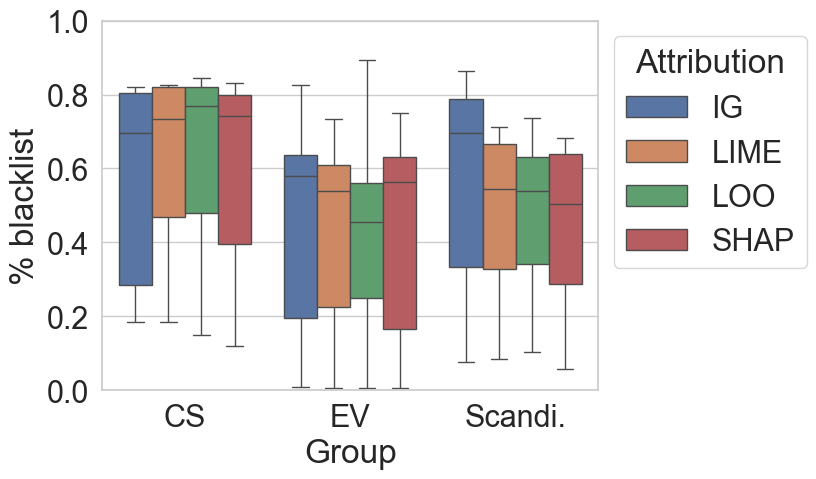

In [4]:
g = sns.boxplot(data=df, x='Group', y='% blacklist', hue='Attribution', hue_order=sorted(df.Attribution.unique()), dodge=True)
g.set(ylim=(0,1))
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
g.get_figure().savefig('prop_blacklist.pdf', bbox_inches='tight')

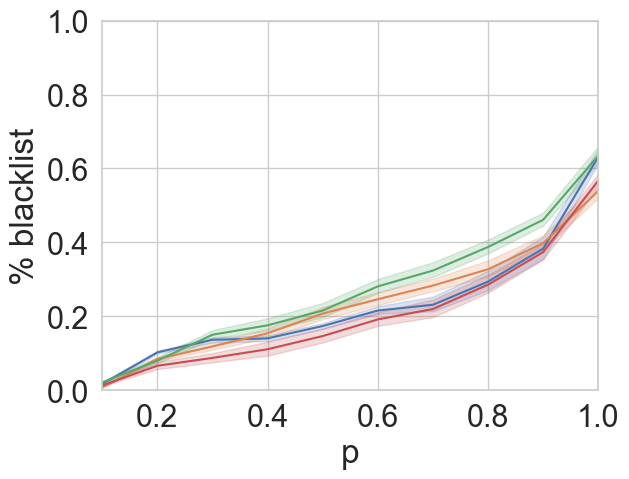

In [11]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'EV')], y='% blacklist', x='p', hue='Attribution', hue_order=sorted(df.Attribution.unique()), legend=False)
g.set(ylim=(0,1), xlim=(0.1,1.0))
g.get_figure().savefig('blacklist_v_p.ev.pdf', bbox_inches='tight')

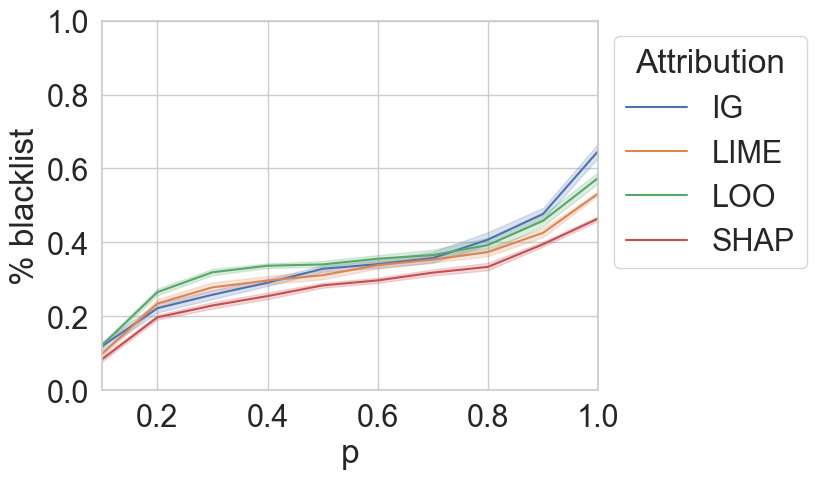

In [25]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'Scandi.')], y='% blacklist', x='p', hue='Attribution', hue_order=sorted(df.Attribution.unique()))
sns.move_legend(g, 'upper left', bbox_to_anchor=(1, 1))
g.set(ylim=(0,1), xlim=(0.1,1.0))
g.get_figure().savefig('blacklist_v_p.scandi.pdf', bbox_inches='tight')

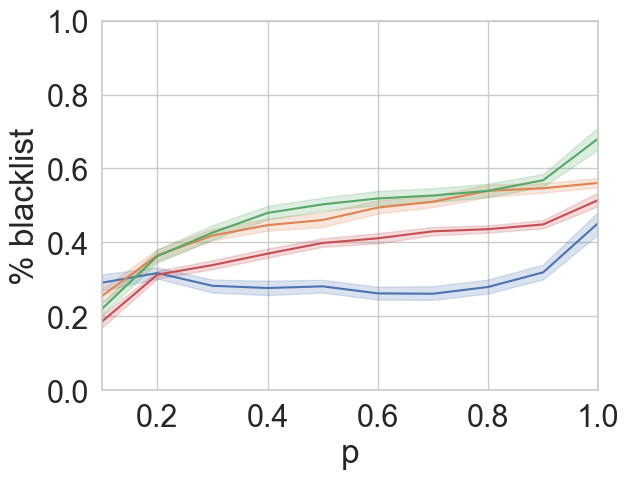

In [13]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'CS')], y='% blacklist', x='p', hue='Attribution', hue_order=sorted(df.Attribution.unique()), legend=False)
g.set(ylim=(0,1), xlim=(0.1,1.0))
g.get_figure().savefig('blacklist_v_p.bcms_s.pdf', bbox_inches='tight')

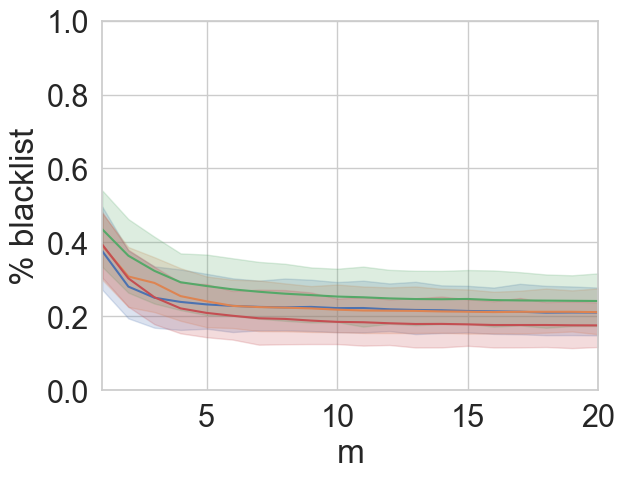

In [14]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'EV')], y='% blacklist', x='m', hue='Attribution', hue_order=sorted(df.Attribution.unique()), legend=False)
g.set(ylim=(0,1), xlim=(1, 20))
g.get_figure().savefig('blacklist_v_m.ev.pdf', bbox_inches='tight')

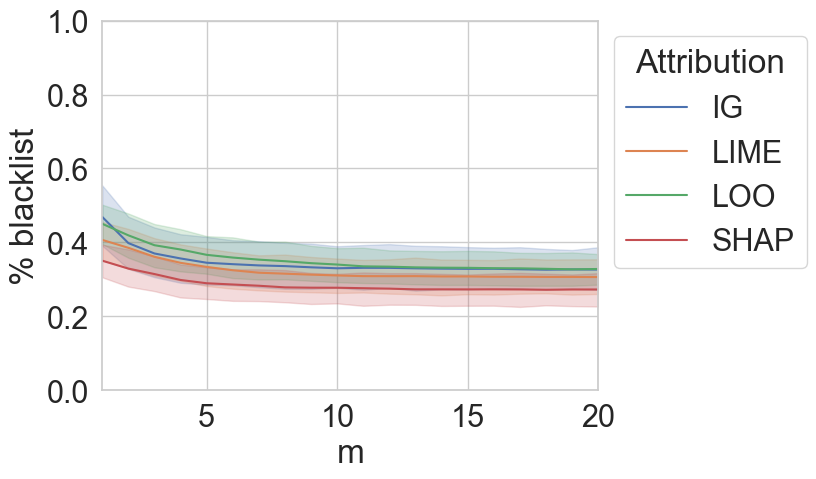

In [24]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'Scandi.')], y='% blacklist', x='m', hue='Attribution', hue_order=sorted(df.Attribution.unique()))
sns.move_legend(g, 'upper left', bbox_to_anchor=(1, 1))
g.set(ylim=(0,1), xlim=(1, 20))
g.get_figure().savefig('blacklist_v_m.scandi.pdf', bbox_inches='tight')

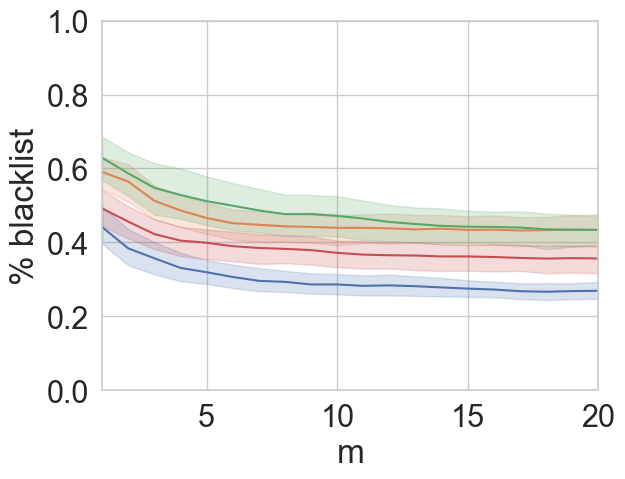

In [15]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'CS')], y='% blacklist', x='m', hue='Attribution', hue_order=sorted(df.Attribution.unique()), legend=False)
g.set(ylim=(0,1), xlim=(1, 20))
g.get_figure().savefig('blacklist_v_m.bcms_s.pdf', bbox_inches='tight')

In [ ]:
def do_bnorm(obs):
    obs = obs.apply(int)
    return ((obs - obs.min()) / (obs.max() - obs.min())) -0.5

def do_norm(obs):
    return ((obs - obs.min()) / (obs.max() - obs.min())) -0.5

res = smf.ols(
    'blacklist ~ C(Attribution) + C(Group) + do_bnorm(tfidf) + do_bnorm(avg) + do_norm(m) + do_norm(p)', 
    data = df,
).fit()
sumry = res.summary()
sumry

In [ ]:
print(sumry.tables[1].as_latex_tabular())

In [ ]:
res.params

In [ ]:
df = pd.read_csv('scandinavian_lists_overview.csv')
for idx, hparam in enumerate(['attrib', 'mdp', 'thresh', 'docnorm', 'tfidf']):
    df[hparam] = df.fname.apply(lambda fname: fname[:-len('.csv')].split('.', 2)[2].split('_')[idx][len(hparam)+1:])
df['mdp'] = df.mdp.apply(int)
df['thresh'] = df.thresh.apply(float)
df1 = df
df

In [ ]:
sns.scatterplot(data=df1, x='prop_bl', y='thresh', hue='docnorm')

In [ ]:
df['norm_setup'] =  df.apply(lambda row: row['docnorm'] + row['tfidf'], axis=1)
g = sns.FacetGrid(data=df[df.docnorm == 'T'], row='attrib', col='thresh', hue='norm_setup')
g.map(sns.lineplot, 'mdp', 'prop_bl')

In [ ]:
sns.stripplot(data=df[df.docnorm == 'T'], hue='attrib', x='thresh', y='prop_lt5', dodge=True)

In [ ]:
df = pd.read_csv('estonian_voro_lists_overview.csv')
for idx, hparam in enumerate(['attrib', 'mdp', 'thresh', 'docnorm', 'tfidf']):
    df[hparam] = df.fname.apply(lambda fname: fname[:-len('.csv')].split('.', 2)[2].split('_')[idx][len(hparam)+1:])
df['mdp'] = df.mdp.apply(int)
df['thresh'] = df.thresh.apply(float)
df2 = df
df

In [ ]:
df['norm_setup'] =  df.apply(lambda row: row['docnorm'] + row['tfidf'], axis=1)
g = sns.FacetGrid(data=df[df.docnorm == 'T'], row='attrib', col='thresh', hue='norm_setup')
g.map(sns.lineplot, 'mdp', 'prop_bl')

In [ ]:
sns.stripplot(data=df[df.docnorm == 'T'], hue='attrib', x='thresh', y='prop_lt5', dodge=True)

In [ ]:
df = pd.read_csv('bcms_setimes_lists_overview.csv')
for idx, hparam in enumerate(['attrib', 'mdp', 'thresh', 'docnorm', 'tfidf']):
    df[hparam] = df.fname.apply(lambda fname: fname[:-len('.csv')].split('.', 2)[2].split('_')[idx][len(hparam)+1:])
df['mdp'] = df.mdp.apply(int)
df['thresh'] = df.thresh.apply(float)
df3 = df
df

In [ ]:
df['norm_setup'] =  df.apply(lambda row: row['docnorm'] + row['tfidf'], axis=1)
g = sns.FacetGrid(data=df[df.docnorm == 'T'], row='attrib', col='thresh', hue='norm_setup')
g.map(sns.lineplot, 'mdp', 'prop_bl')

In [ ]:
sns.stripplot(data=df[df.docnorm == 'T'], hue='attrib', x='thresh', y='prop_lt5', dodge=True)

In [ ]:

df1['Group'] = 'Scandi.'
df2['Group'] = 'EV'
df3['Group'] = 'BCMS (S)'
df = pd.concat([df1, df2, df3]).groupby(['Group', 'attrib', 'thresh']).mean(numeric_only=True).reset_index()
df['1'] = df['prop_happaxes']
df['2'] = df['prop_lt2'] - df['1']
df['3'] = df['prop_lt3'] - df['2'] - df['1']
df['4'] = df['prop_lt4'] - df['3'] - df['2'] - df['1']
df['5'] = df['prop_lt5'] - df['4'] - df['3'] - df['2'] - df['1']
df['6+'] = 1 - df['5'] - df['4'] - df['3'] - df['2'] - df['1']

df = df.melt(
    id_vars=['Group', 'attrib', 'thresh'], 
    value_vars=['1', '2', '3', '4', '5', '6+'][::-1], 
    value_name='prop', 
    var_name='freq',
).rename(columns={'attrib': 'Attribution'})
df

In [ ]:
alt.Chart(df[df.Attribution == 'loo']).mark_bar().encode(
    x=alt.X('thresh:O', title=None),
    y=alt.Y('prop:Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('Group:N', title=None),
    color=alt.Color('freq:O') #, scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69']))
).configure_view(
    strokeOpacity=0    
)

In [ ]:
alt.Chart(df[df.Attribution == 'ig']).mark_bar().encode(
    x=alt.X('thresh:O', title=None),
    y=alt.Y('prop:Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('Group:N', title=None),
    color=alt.Color('freq:O') #, scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69']))
).configure_view(
    strokeOpacity=0    
)

In [ ]:
alt.Chart(df[df.Attribution == 'shap']).mark_bar().encode(
    x=alt.X('thresh:O', title=None),
    y=alt.Y('prop:Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('Group:N', title=None),
    color=alt.Color('freq:O') #, scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69']))
).configure_view(
    strokeOpacity=0    
)

In [ ]:
alt.Chart(df[df.Attribution == 'lime']).mark_bar().encode(
    x=alt.X('thresh:O', title=None),
    y=alt.Y('prop:Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('Group:N', title=None),
    color=alt.Color('freq:O') #, scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69']))
).configure_view(
    strokeOpacity=0    
)